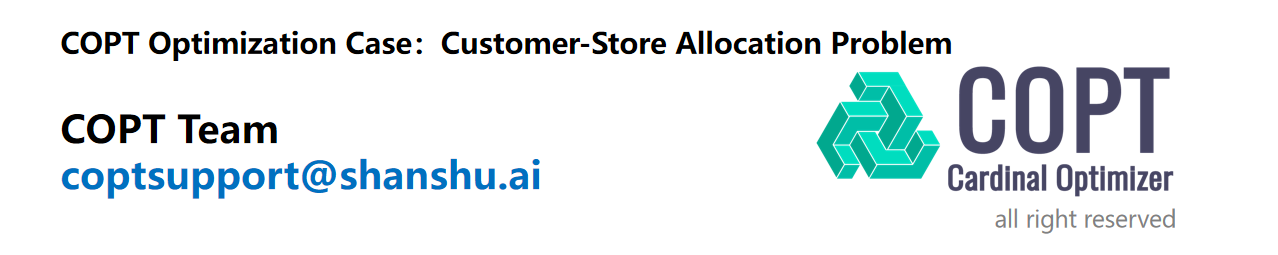

> **Open in Google Colab.** The next cell installs `coptpy`. The bundled free license is size-limited but covers this case. Then run *Runtime > Run all*.


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy matplotlib numpy


# Customer-Store Allocation Problem Code Implementation

## Steps to Model and Solve Customer-Store Allocation Problem Using COPT

1. **Import COPT-Python API** `coptpy`

2. **Add and Preprocess Model Data**
    - Import customer preference data for stores
    - Construct auxiliary sets (i.e. `cus_store_grid`、`cus_expense_grid`)

3. **Create the COPT Environment and COPT Model**

4. **Add three core components of COPT Model**
    - **Add Decision Variables**：Define binary decision variable $x_{ij}$, indicating whether customer $i$ is assigned to store $j$;
    - **Set Objective Function**：Prioritize maximizing customer quantity first, then maximize total sales revenue;
    - **Add Constraints**：
        - Each customer can enter at most one store.
        - The number of customers entering each store should not exceed its capacity.

5. **Solve**

6. View and interpret the **results**

## Import COPT-Python API

In [4]:
import coptpy as cp
from coptpy import COPT

import numpy as np
import matplotlib.pyplot as plt
import math

## Add Model Data


In [6]:
# There are total 10 customers and 4 stores
# [i, j, s] meas that customer i is willing to go to store j and pay s yuan
cus_store = [[0, 0, 10],
            [0, 2, 15],
            [0, 3, 5],
            [1, 1, 13],
            [1, 3, 15],
            [2, 0, 3],
            [2, 3, 5],
            [3, 0, 10],
            [3, 1, 10],
            [3, 2, 10],
            [3, 3, 10],
            [4, 1, 12],
            [5, 0, 20],
            [5, 2, 25],
            [6, 0, 11],
            [6, 1, 13],
            [6, 3, 14],
            [7, 2, 8],
            [7, 3, 9],
            [8, 0, 16],
            [8, 1, 14],
            [8, 3, 15],
            [9, 0, 9],
            [9, 1, 4],
            [9, 2, 8],
            [9, 3, 8]]
store_capacity = [4, 3, 2, 5]


## Preprocess the Data

In [8]:
# Get the number of customers and stores
num_cus = max(row[0] for row in cus_store) + 1
num_store = max(row[1] for row in cus_store) + 1

# Initialize the adjacency matrix between customers and stores
cus_store_grid = np.zeros((num_cus, num_store))
cus_expense_grid = np.zeros((num_cus, num_store))
# Calculate the specific values of the adjacency matrix.
for row in cus_store:
    cus_store_grid[row[0]][row[1]] = 1
    cus_expense_grid[row[0]][row[1]] = row[2]

## Create the COPT environment and COPT model

In [10]:
env = cp.Envr()
model_1 = env.createModel()

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## Add the Three Core Components of the Model
### Add Decision Variables
$$
    x_{ij} = \begin{cases}
        1, & \text{Customer $i$ is arranged to store $j$} \\
        0, & \text{Customer $i$ is not arranged to store $j$}
    \end{cases}
$$

In [12]:
x = model_1.addMVar((num_cus, num_store), vtype=COPT.BINARY, nameprefix="whether_customer_to_store")

### Set Multi-Objective Functions

**Objective 1: maximize the total number of customers**

The objective function is to **maximize** (`sense=COPT.MAXIMIZE`) the total number of customers entering stores, which is a linear objective.
$$
    \max\sum_{i=0}^{num_{cus}-1}\sum_{j=0}^{num_{store}-1}x_{ij}
$$

In [14]:
model_1.setObjectiveN(
    1,
    sum(x),
    priority=2.0,
    sense=COPT.MAXIMIZE
)

## Install Dependencies
Run the cell below to install this case's requirements into the runtime. No environment switch or kernel change is needed.

In [16]:
model_1.setObjectiveN(
    2,
    sum(x * cus_expense_grid),
    priority=1.0,
    sense=COPT.MAXIMIZE
)

<font color=#0000FF>  
<b>Tip: COPT Multi-Objective Optimization Feature</b>  
</font>  

Starting from version 7.2.8, COPT supports **multi-objective optimization**, currently for **linear objective functions** (both continuous and discrete). You can define multiple objectives using the `Model.setObjectiveN()` method and assign each one a `priority` or `weight`.

When solving multi-objective models, COPT supports both the **hierarchy method** and the **weighted-sum method**.
For details, please refer to the [**COPT User Manual: Multi-Objective Optimization**](https://guide.coap.online/copt/en-doc/multiobj.html).


### Add Constraints

1. Each customer can enter at most one store.
$$
    \sum_{j=0}^{num_{store}-1}x_{ij} \leq 1, \quad \forall i=0, 1, \cdots, num_{cus} - 1
$$

In [20]:
model_1.addConstrs(sum(x[i]) <= 1 for i in range(num_cus))

2. The number of customers entering each store should not exceed its capacity.
$$
    \sum_{i=0}^{num_{cus}-1}x_{ij} \leq c_j, \quad \forall j=0, 1, \cdots, num_{store} - 1
$$

In [22]:
model_1.addConstrs(cp.quicksum(x[i, j].item() for i in range(num_cus)) <= store_capacity[j] for j in range(num_store))

## Solve

In [24]:
model_1.solve()

Model fingerprint: 3da29448

Start the multi-objective optimization with 2 objectives

Using hierarchy method for 2 objective groups

Solving the 0-th objective group (priority=2)

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a MIP problem

The original problem has:
    14 rows, 40 columns and 80 non-zero elements
    40 binaries

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    14 rows, 40 columns and 80 non-zero elements
    40 binaries

Problem info:
    Range of matrix coefficients:    [1e+00,1e+00]
    Range of rhs coefficients:       [1e+00,5e+00]
    Range of bound coefficients:     [1e+00,1e+00]
    Range of cost coefficients:      [1e+00,1e+00]
    Density of cost:                     100.0%

     Nodes    Active  LPit/n  IntInf     BestBo

## Solve and Retrieve Results

Optimal total number of customers:10.0
Optimal total revenue:130.0 yuan
Customers are allocated as following:


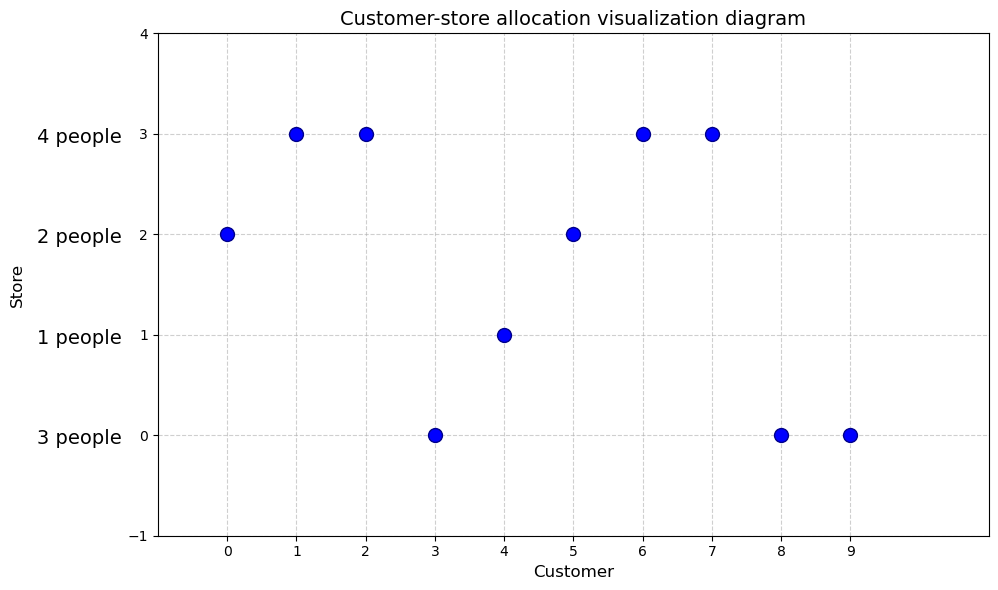

In [26]:
if model_1.status == COPT.OPTIMAL:
    print(f'Optimal total number of customers:{model_1.getAttrN(1, "BestObj")}')
    print(f'Optimal total revenue:{model_1.getAttrN(2, "BestObj")} yuan')
    print('Customers are allocated as following:')
    variables = model_1.getVars()
    solution_x = [[variables[i * num_store + j].x for j in range(num_store)] for i in range(num_cus)]
    answer = []
    num_actual = [0 for i in range(num_store)]
    for i in range(num_cus):
        if sum(solution_x[i][j] for j in range(num_store)) == 1:
            t = 0
            for k in range(num_store):
                if solution_x[i][k] == 1:
                    t = k
                    break
            answer.append([i, t])
            num_actual[t] += 1
        else:
            answer.append([i, -1])

    # visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    for i in range(num_cus):
        if answer[i][1] != -1:
            ax.scatter(answer[i][0], answer[i][1], marker='o', s=100, c='blue', edgecolor='darkblue', linewidth=1, zorder=5)
    for j in range(num_store):
        ax.text(-2.75, j - 0.09, f'{num_actual[j]} people', fontsize=14, color='black')
    ax.set_xlabel('Customer', fontsize=12)
    ax.set_ylabel('Store', fontsize=12)
    ax.set_xticks(np.arange(0, num_cus, 1))
    ax.yaxis.set_label_coords(-0.16, 0.5)
    ax.set_title('Customer-store allocation visualization diagram', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_xlim(-1, num_cus + 1)
    ax.set_ylim(-1, num_store)
    plt.tight_layout()
    plt.show()
else:
    print('No optimal solution found.')

# Case Expansion: Customer-store allocation problem with weight parameters Code Implementation

The overall steps are completely consistent with the original case, with only changes in the model part. By using `w` to adjust the weights of both factors, the objective function becomes:
$$
    \max\sum_{i=0}^{num_{cus}-1}\sum_{j=0}^{num_{store}-1}x_{ij} + \omega\sum_{i=0}^{num_{cus}-1}\sum_{j=0}^{num_{store}-1}x_{ij}\cdot s_{ij}
$$

## Create the Solver Environment and Optimization Model

At the beginning, we create a new model object within the COPT environment to represent the optimization model with weight parameter.

In [29]:
model_2 = env.createModel()

## Add the Three Core Components of the Model
### Add Decision Variables
$$
    x_{ij} = \begin{cases}
        1, & \text{Customer $i$ is arranged to store $j$} \\
        0, & \text{Customer $i$ is not arranged to store $j$}
    \end{cases}
$$

In [31]:
x = model_2.addMVar((num_cus, num_store), vtype=COPT.BINARY, nameprefix="whether_customer_to_store")

### Calculate the weight
`w` is obtained by taking the average consumption amount from random customers to random feasible stores, thereby enabling the normalization of the two objective functions.

In [33]:
w = 0
for item in cus_store:
    w += item[2]
w /= len(cus_store)

### Set Objective Function

Comprehensively consider both objectives through weight parameter `w`.
$$
    \max\sum_{i=0}^{num_{cus}-1}\sum_{j=0}^{num_{store}-1}x_{ij} + \omega\sum_{i=0}^{num_{cus}-1}\sum_{j=0}^{num_{store}-1}x_{ij}\cdot s_{ij}
$$

In [35]:
model_2.setObjective(sum(x) + w * sum(x * cus_expense_grid), sense = COPT.MAXIMIZE)

### Add Constraints

1. Each customer can enter at most one store.
$$
    \sum_{j=0}^{num_{store}-1}x_{ij} \leq 1, \quad \forall i=0, 1, \cdots, num_{cus} - 1
$$
2. The number of customers entering each store should not exceed its capacity.
$$
    \sum_{i=0}^{num_{cus}-1}x_{ij} \leq c_j, \quad \forall j=0, 1, \cdots, num_{store} - 1
$$

In [38]:
model_2.addConstrs(sum(x[i]) <= 1 for i in range(num_cus))
model_2.addConstrs(cp.quicksum(x[i, j].item() for i in range(num_cus)) <= store_capacity[j] for j in range(num_store))


## Solve

In [40]:
model_2.solve()

Model fingerprint: 65489985

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Maximizing a MIP problem

The original problem has:
    14 rows, 40 columns and 80 non-zero elements
    40 binaries

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    14 rows, 40 columns and 80 non-zero elements
    40 binaries

Problem info:
    Range of matrix coefficients:    [1e+00,1e+00]
    Range of rhs coefficients:       [1e+00,5e+00]
    Range of bound coefficients:     [1e+00,1e+00]
    Range of cost coefficients:      [1e+00,3e+02]
    Density of cost:                     100.0%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --       0  3.319385e+03            --     Inf  0.04s
H        0         1      --       0  3

以上是多目标优化的求解日志，可以看出求解的顺序是按照priority进行的。

## Solve and Retrieve Results

Optimal total number of customers:10.0 
Optimal total revenue:130.0  yuan
Customers are allocated as following:


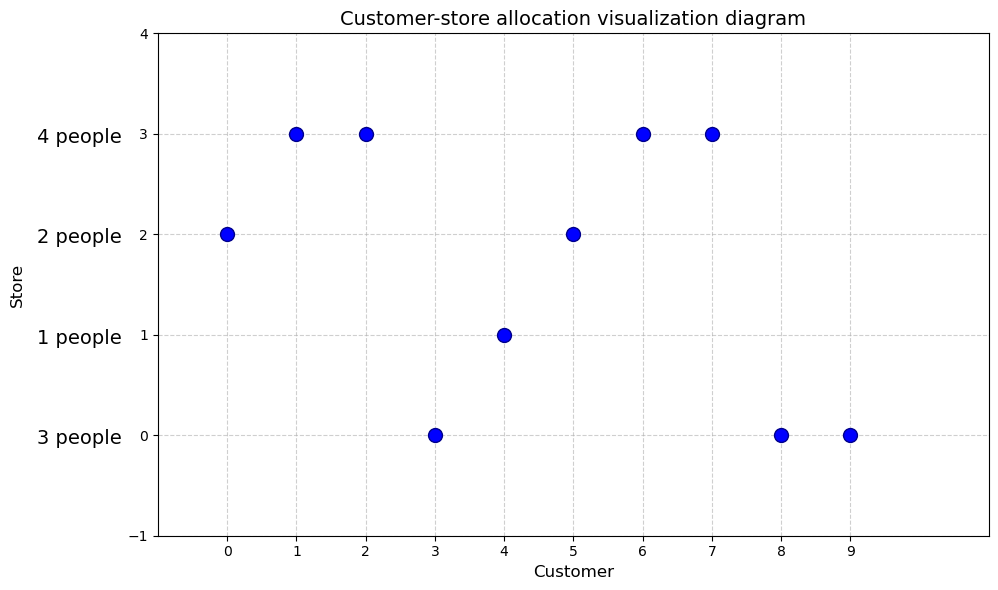

In [43]:
if model_2.status == COPT.OPTIMAL:
    variables = model_2.getVars()
    # The optimal also need to be changed
    print(f'Optimal total number of customers:{cp.quicksum(cp.quicksum(variables[i * num_store + j].x for j in range(num_store)) for i in range(num_cus))}')
    print(f'Optimal total revenue:{cp.quicksum(cp.quicksum(variables[i * num_store + j].x * cus_expense_grid[i][j] for j in range(num_store)) for i in range(num_cus))} yuan')
    print('Customers are allocated as following:')
    variables = model_2.getVars()
    solution_x = [[variables[i * num_store + j].x for j in range(num_store)] for i in range(num_cus)]
    answer = []
    num_actual = [0 for i in range(num_store)]
    for i in range(num_cus):
        if sum(solution_x[i][j] for j in range(num_store)) == 1:
            t = 0
            for k in range(num_store):
                if solution_x[i][k] == 1:
                    t = k
                    break
            answer.append([i, t])
            num_actual[t] += 1
        else:
            answer.append([i, -1])

    # visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    for i in range(num_cus):
        if answer[i][1] != -1:
            ax.scatter(answer[i][0], answer[i][1], marker='o', s=100, c='blue', edgecolor='darkblue', linewidth=1, zorder=5)
    for j in range(num_store):
        ax.text(-2.75, j - 0.09, f'{num_actual[j]} people', fontsize=14, color='black')
    ax.set_xlabel('Customer', fontsize=12)
    ax.set_ylabel('Store', fontsize=12)
    ax.set_xticks(np.arange(0, num_cus, 1))
    ax.yaxis.set_label_coords(-0.16, 0.5)
    ax.set_title('Customer-store allocation visualization diagram', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_xlim(-1, num_cus + 1)
    ax.set_ylim(-1, num_store)
    plt.tight_layout()
    plt.show()
else:
    print('No optimal solution found.')

# Case Expansion: Customer-store allocation with minimum operational standards problem Code Implementation

The overall steps are completely consistent with the original case, with only changes in the model part. By using `op_min` to limit the minimum number of customers served by each store, we add the new constraint:
$$
    \sum_{i=0}^{num_{cus}-1}x_{ij} \geq op_min, \quad \forall j=0, 1, \cdots, num_{store} - 1
$$

## Create the Solver Environment and Optimization Model

At the beginning, we create a new model object within the COPT environment to represent the optimization model with minimum operational standards.

In [46]:
model_3 = env.createModel()

## Add the Three Core Components of the Model
### Add Decision Variables
$$
    x_{ij} = \begin{cases}
        1, & \text{Customer $i$ is arranged to store $j$} \\
        0, & \text{Customer $i$ is not arranged to store $j$}
    \end{cases}
$$

In [48]:
x = model_3.addMVar((num_cus, num_store), vtype=COPT.BINARY, nameprefix="whether_customer_to_store")

### Calculate the minimum operational level
`op_min` is obtained by dividing the total number of customers by the number of stores, then multiplying by $\frac{1}{2}$, and finally rounding up.

In [50]:
op_min = math.ceil(num_cus / num_store / 2)

### Set Multi-Objective Functions
The method for setting up multi-objective functions has already been explained in the original model and will not be reiterated here.

In [52]:
model_3.setObjectiveN(
    1,
    sum(x),
    priority=2.0,
    sense=COPT.MAXIMIZE
)
model_3.setObjectiveN(
    2,
    sum(x * cus_expense_grid),
    priority=1.0,
    sense=COPT.MAXIMIZE
)

1. Each customer can enter at most one store.
$$
    \sum_{j=0}^{num_{store}-1}x_{ij} \leq 1, \quad \forall i=0, 1, \cdots, num_{cus} - 1
$$
2. The number of customers entering each store should not exceed its capacity.
$$
    \sum_{i=0}^{num_{cus}-1}x_{ij} \leq c_j, \quad \forall j=0, 1, \cdots, num_{store} - 1
$$
3. The number of customers at each store should be greater than the minimum operational level.
$$
    \sum_{i=0}^{num_{cus}-1}x_{ij} \geq op_min, \quad \forall j=0, 1, \cdots, num_{store} - 1
$$

In [54]:
model_3.addConstrs(sum(x[i]) <= 1 for i in range(num_cus))
model_3.addConstrs(cp.quicksum(x[i, j].item() for i in range(num_cus)) <= store_capacity[j] for j in range(num_store))
model_3.addConstrs(cp.quicksum(x[i, j].item() for i in range(num_cus)) >= op_min for j in range(num_store))


## Solve

In [56]:
model_3.solve()

Model fingerprint: e7ff3f1e

Start the multi-objective optimization with 2 objectives

Using hierarchy method for 2 objective groups

Solving the 0-th objective group (priority=2)

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a MIP problem

The original problem has:
    18 rows, 40 columns and 120 non-zero elements
    40 binaries

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    17 rows, 40 columns and 110 non-zero elements
    40 binaries

Problem info:
    Range of matrix coefficients:    [1e+00,1e+00]
    Range of rhs coefficients:       [1e+00,5e+00]
    Range of bound coefficients:     [1e+00,1e+00]
    Range of cost coefficients:      [1e+00,1e+00]
    Density of cost:                     75.0%

     Nodes    Active  LPit/n  IntInf     BestB

## Solve and Retrieve Results

Optimal total number of customers:10.0
Optimal total revenue:130.0 yuan
Minimum operational level:2
Customers are allocated as following:


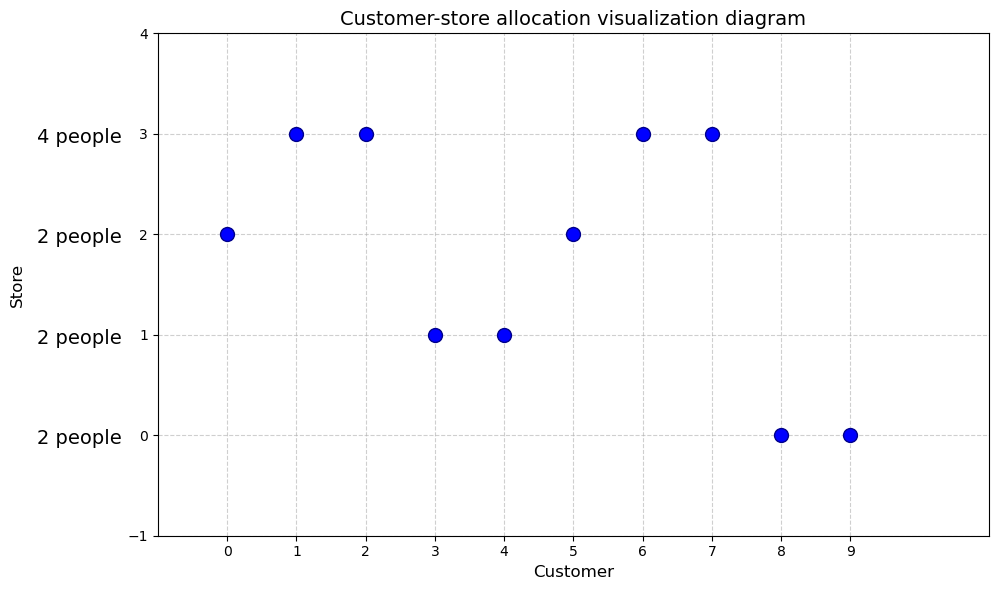

In [58]:
if model_3.status == COPT.OPTIMAL:
    print(f'Optimal total number of customers:{model_3.getAttrN(1, "BestObj")}')
    print(f'Optimal total revenue:{model_3.getAttrN(2, "BestObj")} yuan')
    print(f'Minimum operational level:{op_min}')
    print('Customers are allocated as following:')
    variables = model_3.getVars()
    solution_x = [[variables[i * num_store + j].x for j in range(num_store)] for i in range(num_cus)]
    answer = []
    num_actual = [0 for i in range(num_store)]
    for i in range(num_cus):
        if sum(solution_x[i][j] for j in range(num_store)) == 1:
            t = 0
            for k in range(num_store):
                if solution_x[i][k] == 1:
                    t = k
                    break
            answer.append([i, t])
            num_actual[t] += 1
        else:
            answer.append([i, -1])

    # visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    for i in range(num_cus):
        if answer[i][1] != -1:
            ax.scatter(answer[i][0], answer[i][1], marker='o', s=100, c='blue', edgecolor='darkblue', linewidth=1, zorder=5)
    for j in range(num_store):
        ax.text(-2.75, j - 0.09, f'{num_actual[j]} people', fontsize=14, color='black')
    ax.set_xlabel('Customer', fontsize=12)
    ax.set_ylabel('Store', fontsize=12)
    ax.set_xticks(np.arange(0, num_cus, 1))
    ax.yaxis.set_label_coords(-0.16, 0.5)
    ax.set_title('Customer-store allocation visualization diagram', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_xlim(-1, num_cus + 1)
    ax.set_ylim(-1, num_store)
    plt.tight_layout()
    plt.show()
else:
    print('No optimal solution found.')